# 02 - Data Preprocessing
## Online Shoppers Purchasing Intention Dataset

**Goal of this notebook:**
Based on the insights from `01_EDA.ipynb`, we will now clean and prepare the raw data
so it is ready for feature engineering and modeling. Specifically we will:

1. Load the raw dataset.
2. Handle duplicate rows.
3. Fix data types (correctly mark ID-like integer columns as categorical).
4. Encode categorical variables (`Month`, `VisitorType`, `Weekend`, `OperatingSystems`,
   `Browser`, `Region`, `TrafficType`).
5. Split the data into **Train** and **Test** sets FIRST (before any transformation
   that learns statistics from data, to avoid **data leakage**).
6. Handle outliers / skewness on numerical columns (fit on train, apply to test).
7. Save the cleaned train/test datasets to disk for the next notebook
   (`03_Feature_Engineering.ipynb`).

> **Why split before transforming?** Any transformation that "learns" something from
> the data (like log-transform parameters, scaling means/std, encoding categories)
> must be fit ONLY on the training data and then applied to the test data. This
> mimics a real-world scenario where the test data is "unseen" - fitting on the full
> dataset before splitting would leak information from the test set into training,
> giving unrealistically optimistic results.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Raw Data

In [2]:
DATA_PATH = "../data/online_shoppers_intention.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape before any processing: {df.shape}")
df.head()


Shape before any processing: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Handle Duplicate Rows
As we noted in EDA, some rows are exact duplicates. Since each row is supposed to
represent an independent browsing session, and we have no unique session ID column to
verify otherwise, we treat exact full-row duplicates as redundant information and
remove them. This prevents the model from being biased towards repeated patterns and
also reduces the risk of the same session appearing in both train and test sets after
the split.

In [3]:
duplicate_count_before = df.duplicated().sum()
print(f"Duplicate rows before removal: {duplicate_count_before}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape after removing duplicates: {df.shape}")
print(f"Duplicate rows after removal: {df.duplicated().sum()}")


Duplicate rows before removal: 125
Shape after removing duplicates: (12205, 18)
Duplicate rows after removal: 0


## 4. Fix Data Types

- `OperatingSystems`, `Browser`, `Region`, `TrafficType` are stored as integers but
  are actually categorical IDs (nominal, not ordinal). We convert them to `category`
  / `object` dtype so we treat them correctly during encoding.
- `Weekend` and `Revenue` are boolean; we keep `Weekend` as a feature and separate
  out `Revenue` as our target label (converted to int 0/1 for modeling convenience).


In [4]:
id_like_categorical_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

for col in id_like_categorical_cols:
    df[col] = df[col].astype('category')

# Convert boolean Weekend to int (0/1) - simple binary encoding
df['Weekend'] = df['Weekend'].astype(int)

# Convert target Revenue (True/False) to int (1/0) for modeling
df['Revenue'] = df['Revenue'].astype(int)

df.dtypes


Administrative                int64
Administrative_Duration     float64
Informational                 int64
Informational_Duration      float64
ProductRelated                int64
ProductRelated_Duration     float64
BounceRates                 float64
ExitRates                   float64
PageValues                  float64
SpecialDay                  float64
Month                           str
OperatingSystems           category
Browser                    category
Region                     category
TrafficType                category
VisitorType                     str
Weekend                       int64
Revenue                       int64
dtype: object

## 5. Encode Categorical Text Columns

- **`Month`**: Nominal categorical variable with 10 categories. We will One-Hot
  Encode this later using `pd.get_dummies`, fit only on the training set's observed
  categories to avoid leakage, and align the test set's columns to match.
- **`VisitorType`**: Has 3 categories (`Returning_Visitor`, `New_Visitor`,
  `Other`). Also One-Hot Encoded.
- **`OperatingSystems`, `Browser`, `Region`, `TrafficType`**: High-cardinality ID-like
  categoricals. One-Hot Encoding these would create many sparse columns. Since our
  planned models (Random Forest, XGBoost, LightGBM) are all **tree-based**, they can
  work directly with integer-encoded categories reasonably well. We will keep these as
  integer-encoded (their original numeric codes) rather than one-hot encoding them, to
  keep the feature space manageable. This is a deliberate modeling choice explained
  in comments below.


In [5]:
# Let's check cardinality again to justify our encoding strategy
for col in ['Month', 'VisitorType'] + id_like_categorical_cols:
    print(f"{col}: {df[col].nunique()} unique categories -> {sorted(df[col].unique().tolist(), key=str)}")


Month: 10 unique categories -> ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']
VisitorType: 3 unique categories -> ['New_Visitor', 'Other', 'Returning_Visitor']
OperatingSystems: 8 unique categories -> [1, 2, 3, 4, 5, 6, 7, 8]
Browser: 13 unique categories -> [1, 10, 11, 12, 13, 2, 3, 4, 5, 6, 7, 8, 9]
Region: 9 unique categories -> [1, 2, 3, 4, 5, 6, 7, 8, 9]
TrafficType: 20 unique categories -> [1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20, 3, 4, 5, 6, 7, 8, 9]


## 6. Train-Test Split (BEFORE further transformations)

We split the data into 80% training and 20% testing, using **stratified sampling**
on the target `Revenue` so both sets preserve the same ~15.5% purchase rate. This is
important for an imbalanced dataset - a random (non-stratified) split could
accidentally create a test set with a very different class balance.

We set a fixed `random_state` for reproducibility.


In [6]:
TARGET = 'Revenue'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # preserve class distribution in both sets
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Train purchase rate: {y_train.mean():.4f}")
print(f"Test purchase rate:  {y_test.mean():.4f}")


X_train shape: (9764, 17)
X_test shape:  (2441, 17)
Train purchase rate: 0.1563
Test purchase rate:  0.1565


## 7. One-Hot Encode `Month` and `VisitorType`

We fit the encoding (i.e., determine which dummy columns to create) using only the
**training set's** categories, then apply the exact same columns to the test set.
Any category that might appear in test but not in train (not expected here, but good
practice) will simply not get a dummy column - we align columns explicitly using
`reindex` to guarantee train/test have identical columns in the same order.


In [7]:
categorical_to_onehot = ['Month', 'VisitorType']

X_train_encoded = pd.get_dummies(X_train, columns=categorical_to_onehot, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_to_onehot, drop_first=False)

# Align test set columns to match train set columns exactly (fill missing with 0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape:  {X_test_encoded.shape}")
X_train_encoded.head()


X_train_encoded shape: (9764, 28)
X_test_encoded shape:  (2441, 28)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
7469,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,37.357258,0.0,2,2,5,2,0,False,False,False,False,False,False,False,True,False,False,False,False,True
11804,0,0.0,0,0.0,30,901.288889,0.0,0.007333,34.148420,0.0,2,2,7,2,0,False,True,False,False,False,False,False,False,False,False,True,False,False
3250,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.000000,0.8,1,1,1,2,0,False,False,False,False,False,False,True,False,False,False,False,False,True
204,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.000000,0.0,2,2,7,2,1,False,False,False,False,False,True,False,False,False,False,True,False,False
4392,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.000000,0.0,4,2,2,13,0,False,False,False,False,False,False,True,False,False,False,False,False,True


## 8. Ensure ID-like Categorical Columns are Numeric (int codes)

Since we chose to keep `OperatingSystems`, `Browser`, `Region`, `TrafficType` as their
original integer codes (not one-hot encoded), we just need to make sure they are
stored as plain integers (not pandas `category` dtype) so downstream libraries like
scikit-learn/XGBoost/LightGBM handle them without issues.


In [8]:
for col in id_like_categorical_cols:
    X_train_encoded[col] = X_train_encoded[col].astype(int)
    X_test_encoded[col] = X_test_encoded[col].astype(int)

X_train_encoded.dtypes


Administrative                     int64
Administrative_Duration          float64
Informational                      int64
Informational_Duration           float64
ProductRelated                     int64
ProductRelated_Duration          float64
BounceRates                      float64
ExitRates                        float64
PageValues                       float64
SpecialDay                       float64
OperatingSystems                   int64
Browser                            int64
Region                             int64
TrafficType                        int64
Weekend                            int64
Month_Aug                           bool
Month_Dec                           bool
Month_Feb                           bool
Month_Jul                           bool
Month_June                          bool
Month_Mar                           bool
Month_May                           bool
Month_Nov                           bool
Month_Oct                           bool
Month_Sep       

## 9. Handle Skewness in Numerical Features (Log Transformation)

From EDA we saw heavy right-skew in duration/count/rate features, with many
legitimate high values (e.g. `PageValues`) that we do NOT want to delete as
"outliers" since they are likely strong predictors. Instead of removing outlier rows
(which would lose valuable information and shrink our already-imbalanced minority
class), we apply a **log1p transform** (`log(1 + x)`) to compress the long right
tail while keeping all data points. `log1p` is used (instead of plain `log`) because
several of these columns contain zeros, and `log(0)` is undefined.

This transform is deterministic (no parameters learned from data), so it is safe to
apply identically to both train and test without leakage.


In [9]:
skewed_cols = ['Administrative_Duration', 'Informational_Duration',
               'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

# Check skewness before transform
print("Skewness BEFORE log transform:")
print(X_train_encoded[skewed_cols].skew())


Skewness BEFORE log transform:
Administrative_Duration    5.676854
Informational_Duration     7.542680
ProductRelated_Duration    7.871851
BounceRates                3.173039
ExitRates                  2.236878
PageValues                 6.547283
dtype: float64


In [10]:
for col in skewed_cols:
    X_train_encoded[col] = np.log1p(X_train_encoded[col])
    X_test_encoded[col] = np.log1p(X_test_encoded[col])

print("Skewness AFTER log transform:")
print(X_train_encoded[skewed_cols].skew())


Skewness AFTER log transform:
Administrative_Duration    0.239742
Informational_Duration     1.913131
ProductRelated_Duration   -1.431148
BounceRates                3.089297
ExitRates                  2.132025
PageValues                 1.797034
dtype: float64


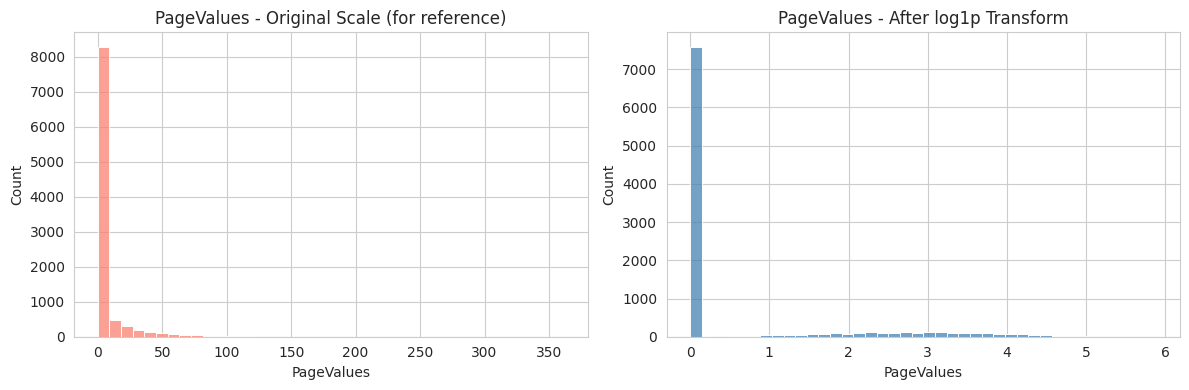

In [11]:
# Visual check: before vs after distribution for PageValues as an example
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.expm1(X_train_encoded['PageValues']), bins=40, ax=axes[0], color='salmon')
axes[0].set_title('PageValues - Original Scale (for reference)')
sns.histplot(X_train_encoded['PageValues'], bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('PageValues - After log1p Transform')
plt.tight_layout()
plt.show()


**Observation:** The log1p transform substantially reduces skewness across all
targeted columns, making distributions more symmetric/model-friendly, while preserving
every single data point (no rows dropped).


## 10. Final Sanity Checks

In [12]:
print("Any missing values in X_train_encoded?", X_train_encoded.isnull().sum().sum())
print("Any missing values in X_test_encoded?", X_test_encoded.isnull().sum().sum())
print("Columns match between train and test?", list(X_train_encoded.columns) == list(X_test_encoded.columns))
print()
print("Final X_train_encoded columns:")
print(X_train_encoded.columns.tolist())


Any missing values in X_train_encoded? 0
Any missing values in X_test_encoded? 0
Columns match between train and test? True

Final X_train_encoded columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor', 'VisitorType_Other', 'VisitorType_Returning_Visitor']


## 11. Save Processed Data

We save the cleaned & encoded train/test sets (features and target separately) as CSV
files inside `data/processed/`. The next notebook (`03_Feature_Engineering.ipynb`)
will load these files and build new engineered features on top of this clean base.


In [13]:
import os
os.makedirs('../data/processed', exist_ok=True)

X_train_encoded.to_csv('../data/processed/X_train_preprocessed.csv', index=False)
X_test_encoded.to_csv('../data/processed/X_test_preprocessed.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Preprocessed data saved to ../data/processed/")
print("Files created:")
for f in os.listdir('../data/processed'):
    print(" -", f)


Preprocessed data saved to ../data/processed/
Files created:
 - y_train.csv
 - X_train_preprocessed.csv
 - y_test.csv
 - X_test_preprocessed.csv


## 12. Summary

- Removed exact duplicate rows.
- Correctly typed ID-like categorical columns (`OperatingSystems`, `Browser`,
  `Region`, `TrafficType`) as categorical, kept as integer codes for tree models.
- One-hot encoded `Month` and `VisitorType`, fit strictly on the training set.
- Performed an 80/20 stratified train-test split BEFORE any data-dependent
  transformation, to avoid data leakage.
- Applied a `log1p` transform to reduce skewness in duration/rate/PageValues columns
  without discarding any outlier rows (since many of these are genuinely informative,
  not data errors).
- Saved clean train/test feature and target sets for the next stage.

### Next Steps
Proceed to `03_Feature_Engineering.ipynb` to create new, potentially more predictive
features on top of this cleaned dataset.
